# University Student Services AI Agent

Week 5 Assignment

Retrieval-Augmented Generation (RAG) with LangGraph

In [1]:
import os

from dotenv import load_dotenv

from typing import TypedDict, List

from langchain_core.documents import Document

from langchain_openai import (ChatOpenAI, OpenAIEmbeddings)

from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import ChatOllama

from langchain_community.embeddings import HuggingFaceEmbeddings

from langchain_community.tools import DuckDuckGoSearchRun

from langgraph.checkpoint.memory import MemorySaver


from langgraph.graph import (StateGraph,START,END)

#from notebook import workflow

C:\Users\sfolaranmi\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\sfolaranmi\AppData\Local\Temp\ipykernel_5784\812479512.py:15: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


In [2]:
load_dotenv()

True

In [3]:
#load knowledge documents

knowledge_docs = []

folder_path = "./knowledge_documents"

for filename in os.listdir(folder_path):

    if filename.endswith(".txt"):
        file_path = os.path.join(folder_path,filename)
        with open(file_path, "r", encoding="utf-8") as file:
            text = file.read()
            knowledge_docs.append(
                Document(
                    page_content=text,
                    metadata={
                        "source": filename
                    }
                )
            )

print(
    f"Loaded {len(knowledge_docs)} documents"
)

Loaded 8 documents


In [4]:
for doc in knowledge_docs:

    print("=" * 60)

    print(doc.metadata)

    print(doc.page_content[:300])

{'source': 'campus_services_guide.txt'}
UNIVERSITY CAMPUS SERVICES GUIDE

Version 2026

STUDENT HOUSING

The university offers both on-campus and off-campus housing assistance.

Students interested in on-campus housing must submit a Housing Application before July 1.

Housing assignments are made on a first-come, first-served basis.

Resi
{'source': 'career_services_faq.txt'}
CAREER SERVICES FREQUENTLY ASKED QUESTIONS

GENERAL SERVICES

Q: What services are offered?
A: Resume reviews, career coaching, internship support, mock interviews, networking events, employer presentations, and job search assistance.

Q: Are services free?
A: Yes, all currently enrolled students ma
{'source': 'course_registration_guide.txt'}
COURSE REGISTRATION GUIDE
Academic Year 2026–2027

OVERVIEW

The registration process allows students to enroll in courses required for degree completion. Students are responsible for ensuring registration accuracy and compliance with academic policies.

REGISTRATION PERIODS


In [5]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(
    knowledge_docs
)

print(
    f"Created {len(chunks)} chunks"
)

Created 19 chunks


In [6]:
chunks[0]

Document(metadata={'source': 'campus_services_guide.txt'}, page_content='UNIVERSITY CAMPUS SERVICES GUIDE\n\nVersion 2026\n\nSTUDENT HOUSING\n\nThe university offers both on-campus and off-campus housing assistance.\n\nStudents interested in on-campus housing must submit a Housing Application before July 1.\n\nHousing assignments are made on a first-come, first-served basis.\n\nResidence halls include:\n\n- Maple Hall\n- Oak Hall\n- Cedar Hall\n\nLIBRARY SERVICES\n\nThe University Library operates:\n\nMonday - Friday:\n8:00 AM - 10:00 PM\n\nSaturday:\n9:00 AM - 6:00 PM\n\nSunday:\n12:00 PM - 8:00 PM\n\nStudents may borrow up to 10 books simultaneously.\n\nLibrary services include:\n\n- Book lending\n- Research assistance\n- Digital databases\n- Study rooms\n- Printing services\n\nIT SUPPORT\n\nThe IT Help Desk provides technical assistance for:\n\n- Student email accounts\n- Learning Management System access\n- Wi-Fi connectivity\n- Password resets\n- Software installation\n\nSupport H

In [8]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5627.22it/s]


In [9]:
unique_chunks = []
seen = set()

for chunk in chunks:

    content = chunk.page_content.strip()

    if content not in seen:
        seen.add(content)
        unique_chunks.append(chunk)

print(f"Original chunks: {len(chunks)}")
print(f"Unique chunks: {len(unique_chunks)}")

Original chunks: 19
Unique chunks: 19


In [10]:
import shutil

shutil.rmtree("./student_service_db", ignore_errors=True)

In [11]:
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./student_service_db"
)

In [12]:
retriever = vector_store.as_retriever(
    search_kwargs={ "k": 5  }
)

In [13]:
collection = vector_store._collection


In [14]:
print(collection.count())
print(len(chunks))

19
19


In [15]:
llm = ChatOllama(
    model="llama3",
    temperature=0
)


In [16]:
class AgentState(TypedDict, total=False):
    question: str
    route: str
    documents: List[Document]
    answer: str
    reviewed_answer: str
    conversation_history: List[str]

In [17]:
def update_memory(state):

    history = state.get(
        "conversation_history",
        []
    )

    history.append(
        f"User: {state['question']}"
    )

    history.append(
        f"Assistant: {state['reviewed_answer']}"
    )

    return {
        "conversation_history": history
    }

In [18]:
def route_question(state):

    question = state["question"]

    prompt = f"""
    Classify the user question into ONE category.

    Return ONLY one of:

    knowledge
    weather
    web
    general

    Examples:

    What GPA is required for graduation?
    -> knowledge

    What is the tuition refund policy?
    -> knowledge

    What's the weather in Lagos?
    -> weather

    Will it rain tomorrow?
    -> weather

    Who won the last World Cup?
    -> web

    Latest AI news
    -> web

    Tell me a joke
    -> general

    Conversations,Explanations, Programming concepts, General knowledge
    -> general

    Question:
    {question}
    """

    response = llm.invoke(prompt)

    print("RAW RESPONSE:", response.content)

    route = response.content.strip().lower()

    print("Route:", route)

    return {
        "route": route
    }

In [19]:
import requests
OPENWEATHER_API_KEY = os.getenv("OPENWEATHER_API_KEY")

def get_weather(city):

    url = (
        "https://api.openweathermap.org/data/2.5/weather"
    )

    params = {
        "q": city,
        "appid": OPENWEATHER_API_KEY,
        "units": "metric"
    }

    response = requests.get(
        url,
        params=params
    )

    response.raise_for_status()

    return response.json()

In [ ]:
weather = get_weather("Lagos")

In [20]:
def weather_node(state):

    question = state["question"]

    prompt = f"""
    Extract ONLY the city name.

    Examples:

    What is the weather in Lagos?
    -> Lagos

    Will it rain in London today?
    -> London

    What's the weather in New York?
    -> New York

    Question:
    {question}
    """

    city = (
        llm.invoke(prompt).content.strip()
    )

    try:

        weather = get_weather(city)

        temp = weather["main"]["temp"]

        feels_like = weather["main"]["feels_like"]

        description = weather["weather"][0]["description"]

        humidity = weather["main"]["humidity"]

        answer = f"""
Current weather in {city}

Temperature: {temp}°C
Feels Like: {feels_like}°C
Condition: {description}
Humidity: {humidity}%
"""

    except Exception as ex:

        answer = (
            f"Unable to retrieve weather "
            f"information for {city}. "
            f"{str(ex)}"
        )

    return {
        "answer": answer
    }

In [22]:
search_tool = DuckDuckGoSearchRun()

In [23]:
def web_search_node(state):

    result = search_tool.run(
        state["question"]
    )

    return {
        "answer": result
    }

In [24]:
def retrieve_documents(state):

    docs = retriever.invoke(state["question"])

    unique_docs = []
    seen = set()

    for doc in docs:

        content = doc.page_content.strip()

        if content not in seen:
            seen.add(content)
            unique_docs.append(doc)

    return {
        "documents": unique_docs
    }

In [25]:
def generate_rag_answer(state):

    context = "\n\n".join(doc.page_content
        for doc in state["documents"]
    )

    history = "\n".join(
        state.get(
            "conversation_history",
            []
        )
    )

    prompt = f"""You are a university assistant.
    Use ONLY the information contained in the context.
    If the answer cannot be found,
    respond:
    "I could not find that information
    in the university documents."

    Conversation History:
    {history}

    Context:
    {context}

    Question:
    {state['question']}
    """

    answer = (
        llm.invoke(prompt).content
    )

    return {
        "answer": answer
    }

In [26]:
def generate_general_answer(state):

    history = "\n".join(
        state.get(
            "conversation_history",
            []
        )
    )

    prompt = f"""
    Conversation History:
    {history}

    User Question:
    {state['question']}
    """

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

In [27]:
def review_answer(state):

    answer = state["answer"]

    prompt = f"""
    You are an editor.

    Review the answer below.

    If improvements are needed, rewrite the answer.

    If no improvements are needed, return the answer exactly as it is.

    IMPORTANT:
    Return ONLY the final revised answer.
    Do NOT explain your review.
    Do NOT give feedback.
    Do NOT mention clarity, grammar, or completeness.

    Answer:
    {answer}
    """

    response = llm.invoke(prompt)

    return {
        "reviewed_answer": response.content.strip()
    }

In [28]:
def determine_path(state):

    return state["route"]

In [29]:
graph = StateGraph(AgentState)

graph.add_node("web_search", web_search_node)
graph.add_node("weather", weather_node)
graph.add_node("memory", update_memory)
graph.add_node("router", route_question)
graph.add_node("retrieve",retrieve_documents)
graph.add_node("rag_answer", generate_rag_answer)
graph.add_node("general_answer", generate_general_answer)
graph.add_node("review", review_answer)

In [30]:
graph.add_edge( START,"router")

graph.add_conditional_edges("router", determine_path,
    {
        "knowledge": "retrieve",
        "general": "general_answer",
        "weather": "weather",
        "web": "web_search"
    }
)
graph.add_edge("weather", "review")
graph.add_edge("web_search", "review")
graph.add_edge("retrieve", "rag_answer")
graph.add_edge("rag_answer", "review")
graph.add_edge("general_answer", "review")
graph.add_edge("review", "memory")
graph.add_edge("memory", END)

In [31]:
memory = MemorySaver()

workflow = graph.compile(
    checkpointer=memory
)

In [33]:
config = {
    "configurable": {
        "thread_id": "student_demo"
    }
}

In [34]:
result = workflow.invoke({
    "question": "What GPA is required for graduation?"
},
    config=config
)

print(result["route"])
print(result["reviewed_answer"])

RAW RESPONSE: knowledge
Route: knowledge
knowledge
According to the University Student Handbook, Version 2026, a minimum cumulative GPA of 2.5 is required for graduation from undergraduate programs.


In [36]:
result = workflow.invoke({
    "question": "What is the weather in Lagos?"
},
    config=config
)

print(result["route"])
print(result["reviewed_answer"])

RAW RESPONSE: weather
Route: weather
weather
Current weather in Lagos:

Temperature: 33.51°C
Feels Like: 37.66°C
Condition: Overcast clouds
Humidity: 51%


In [45]:
result = workflow.invoke({
    "question": "Who won the 2022 FIFA World Cup?"
},
    config=config
)

print(result["route"])
print(result["reviewed_answer"])

RAW RESPONSE: web
Route: web
web
1 day ago · Champions Argentina: All 2022 World Cup Goals. 50K views · 21 ... 22 hours ago · Watch extended highlights of the epic battle between Lionel Messi and Argentina up against Kylian Mbappe and France in the fantastic final of the 2022 FIFA ... 27 May 2026 · Review the match events and penalty shootout from the 2022 FIFA World Cup Final between Argentina and France in Qatar. The match ended 3-3 after extra time, ... 4 Jan 2026 · Qatar 2022TM Champions: Argentina Runners-up: France Third place: Croatia. Argentina won a third World Cup at Qatar 2022. 2 days ago · Rewatch the full Argentina v France match from FIFA World Cup 2022. FOLLOW FIFA'S TOURNAMENT CHANNELS BELOW! FIFA World Cup: ...


In [46]:
result = workflow.invoke({
    "question": "What are the top 5 latest AI news?"
},
    config=config
)

print(result["route"])
print(result["reviewed_answer"])

RAW RESPONSE: web
Route: web
web
8 hours ago - AI News delivers the latest updates in artificial intelligence, machine learning, deep learning, enterprise AI, and emerging tech worldwide. 8 hours ago - Explore the latest artificial intelligence news with Reuters - from AI breakthroughs and technology trends to regulation, ethics, business and global impact. 9 hours ago - News coverage on artificial intelligence and machine learning tech, the companies building them, and the ethical issues AI raises today. Johnson Agogbua built internet infrastructure for three decades – and now the Kasi Cloud founder is bringing hyperscale, AI-ready data centres to Africa… ... ''When you look at what we are doing, it’s a celebration of a global company partnering with a greenfield in Africa that says world-class belongs in Africa as well'' 14 hours ago - He Blew the Whistle on DOGE. Then His Brakes Were Cut · Vittoria Elliott · Security News · Meta Deletes Face-Recognition System From Its Smart Glasses

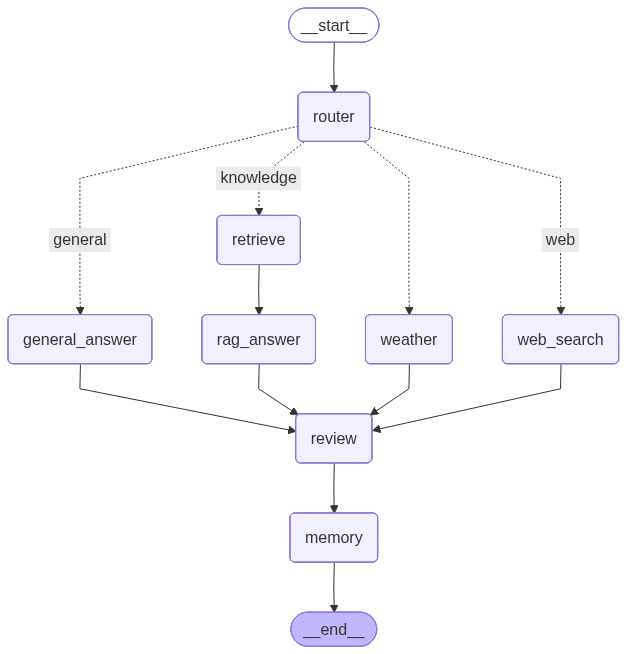

In [50]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [47]:
snapshot = workflow.get_state(config)

print(snapshot.values)

{'question': 'What are the top 5 latest AI news?', 'route': 'web', 'documents': [Document(id='886e407f-d7d2-46f4-b68e-93d1a209ddd7', metadata={'source': 'student_handbook.txt'}, page_content='UNIVERSITY STUDENT HANDBOOK\n\nVersion 2026\n\nACADEMIC POLICIES\n\nStudents are expected to maintain satisfactory academic progress throughout their studies.\n\nA minimum cumulative GPA of 2.5 is required for graduation from undergraduate programs.\n\nStudents whose GPA falls below 2.0 will be placed on Academic Probation.\n\nStudents on Academic Probation for two consecutive semesters may be subject to Academic Suspension.\n\nGRADING SYSTEM\n\nA = 90 - 100\nB = 80 - 89\nC = 70 - 79\nD = 60 - 69\nF = Below 60\n\nATTENDANCE POLICY\n\nStudents must attend at least 75% of all scheduled classes.\n\nStudents who miss more than 25% of classes without approved justification may be barred from taking final examinations.\n\nAbsences due to illness, family emergencies, or university-approved activities may